# Reproduction: Predicting Phenotypic Traits Using a Massive RNA-seq Dataset

**Paper:** Hadish JA, Honaas LA, Ficklin SP. *Predicting Phenotypic Traits Using a Massive RNA-seq Dataset.* bioRxiv 2023.12.05.570195 (DOI: 10.1101/2023.12.05.570195).

**Minimal reproduction scope:** Retrain the authors' **tissue-4 random forest classifier** (Flower / Leaf / Root / Seed) exactly as in the authors' notebook `05-RandomForest_Tissue/04-Confusion_Matrices.ipynb`, using the **archived BioProject-disjoint MRN train/test split pickle** instead of reprocessing 74,833 SRA runs.

**Author code:** GitLab `ficklinlab-public/modeling-with-transcriptomics`, pinned commit `ff7a55102b963506f1af75dc5002f37e48d68527` (CC-BY-4.0).

**Data:** Zenodo record [10183151](https://zenodo.org/records/10183151) (CC-BY-4.0), file `Dataset_Tissue_TrainTestSplits_mrn_4category.pkl.bz2` (2,367,995,587 bytes, md5 `c9af8b151983dd0f426436810f73eba6`).

**Reference results to compare against (paper, test set):** tissue-4 accuracy ≈ 0.994, macro F1 ≈ 0.995.

**Runtime:** CPU only (scikit-learn random forest; no GPU benefit). Standard Colab CPU with ~12.7 GB RAM; the decompressed pickle is several GB, so memory is the main constraint.

**日本語:** このノートブックは、アラビドプシスの大量RNA-seqデータから組織タイプ（4カテゴリ）を予測するランダムフォレスト分類器を、著者らがZenodoに公開したMRN正規化済みtrain/test分割pickleから再学習・検証します。GPUは不要でCPUのみで実行できます。

## 1. Setup

**Purpose / expected result:** Import the libraries used by the authors (pandas, scikit-learn, joblib, matplotlib, seaborn) and print their versions. Expected: no errors; scikit-learn ≥ 1.x available in Colab.

**日本語:** 著者のコードが使用するライブラリをインポートし、バージョンを確認します。

In [ ]:
import bz2, hashlib, joblib, gc, os, pickle, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| joblib", joblib.__version__)

def ram_gb():
    with open("/proc/self/status") as f:
        for line in f:
            if line.startswith("VmRSS"):
                return int(line.split()[1]) / 1e6
print(f"RAM used: {ram_gb():.1f} GB")

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | joblib 1.6.0
RAM used: 0.3 GB


## 2. Download the archived data (Zenodo record 10183151)

**Purpose / expected result:** Download the authors' archived tissue-4 train/test split pickle (`Dataset_Tissue_TrainTestSplits_mrn_4category.pkl.bz2`, ~2.2 GiB compressed) and the tiny names-only TSV that documents the matrix schema. Both are fetched from the Zenodo record API's returned content URL. Expected: both files on disk under `/content` with md5 checksums matching the Zenodo record.

**日本語:** 著者らがZenodoに公開したtrain/test分割pickle（約2.2 GiB、圧縮時）と、スキーマ確認用の小さなnames-only TSVをダウンロードし、md5を検証します。

In [ ]:
import subprocess, hashlib, os

def fetch(fname, expect_md5):
    url = f"https://zenodo.org/api/records/10183151/files/{fname}/content"
    path = f"/content/{fname}"
    subprocess.run(["curl", "-sSL", "--retry", "3", "--retry-delay", "5",
                    "-o", path, url], check=True)
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 22), b""):
            h.update(chunk)
    assert h.hexdigest() == expect_md5, f"md5 mismatch for {fname}"
    print(fname, os.path.getsize(path), "bytes | md5 OK")

fetch("Dataset_Tissue_TrainTestSplits_mrn_4category.pkl.bz2", "c9af8b151983dd0f426436810f73eba6")
fetch("Dataset_Tissue_TrainTestSplits_4category_namesOnly.tsv.bz2", "706e188cabd47da9698e7308104c9fb9")

Dataset_Tissue_TrainTestSplits_mrn_4category.pkl.bz2 2367995587 bytes | md5 OK


Dataset_Tissue_TrainTestSplits_4category_namesOnly.tsv.bz2 22576 bytes | md5 OK


## 3. Inspect the names-only TSV (schema without the heavy matrix)

**Purpose / expected result:** The 22 KB `namesOnly` TSV lists sample and gene column names of the archived split. Expected: ~4 category-relevant tissue samples and the gene column list; this confirms the pickle structure `[x_train, y_train, x_test, y_test]` before loading gigabytes.

**日本語:** 巨大なpickleを読む前に、22 KBのnames-only TSVで行列の構成（サンプル名・遺伝子名）を確認します。

In [ ]:
import bz2, pandas as pd
with bz2.open("/content/Dataset_Tissue_TrainTestSplits_4category_namesOnly.tsv.bz2", "rt") as f:
    names_tsv = pd.read_csv(f, sep="\t")
print(names_tsv.shape)
names_tsv.head()

(9169, 2)


,experiment,train_test
0,SRX082186,train
1,SRX082188,train
2,SRX082189,train
3,SRX084369,train
4,SRX10023755,train


## 4. Decompress and load the MRN tissue-4 split pickle

**Purpose / expected result:** Load the authors' archived split with `joblib.load`, which transparently handles the `.bz2` compression and the joblib/pickle payload (a plain `pickle.load` on the bz2 stream fails with `invalid load key`). The authors' notebooks expect the structure `[x_train, y_train, x_test, y_test]`, where the `y` DataFrames contain columns `bio_sample`, `tissue`, `tissue_6` (holding the 4 tissue categories) and `bioproject_name`. Expected: printed shapes; the label column contains exactly {Flower, Leaf, Root, Seed}.

**日本語:** `joblib.load`でアーカイブ（.bz2圧縮＋joblib pickle）を直接読み込み、形状とラベル（Flower / Leaf / Root / Seed）を確認します。

In [ ]:
import joblib, time
t0 = time.time()
split = joblib.load("/content/Dataset_Tissue_TrainTestSplits_mrn_4category.pkl.bz2")
print(f"loaded in {time.time()-t0:.0f} s")
x_train, y_train, x_test, y_test = split
print("x_train", x_train.shape, "| x_test", x_test.shape)
print("y_train columns:", list(y_train.columns))
print("train labels:", y_train["tissue_6"].value_counts().to_dict())
print("test labels:", y_test["tissue_6"].value_counts().to_dict())
print("train BioProjects:", y_train["bioproject_name"].nunique(), "| test BioProjects:", y_test["bioproject_name"].nunique())
print(f"RAM used: {ram_gb():.1f} GB")

loaded in 181 s
x_train (7181, 43224) | x_test (1988, 43224)
y_train columns: ['bio_sample', 'tissue', 'tissue_6', 'bioproject_name']
train labels: {'leaf': 4216, 'root': 1920, 'flower': 603, 'seed': 442}
test labels: {'leaf': 1105, 'root': 516, 'seed': 247, 'flower': 120}
train BioProjects: 529 | test BioProjects: 141
RAM used: 3.4 GB


## 5. Train the tissue-4 random forest with the authors' final parameters

**Purpose / expected result:** Fit `RandomForestClassifier(n_estimators=300, min_samples_leaf=3, max_depth=7, bootstrap=False, max_features=700)` on `x_train` with label `y_train["tissue_6"]` — exactly the parameters used in the authors' `04-Confusion_Matrices.ipynb` (cell 19) after their RandomizedSearchCV tuning (`n_jobs=-1` uses all Colab vCPUs instead of the authors' 7-core Kamiak node). Expected: training completes in ~10–30 minutes on 2 vCPUs.

**日本語:** 著者のコードと同一の最終ハイパーパラメータでランダムフォレストを学習します（`n_jobs`のみColabの全コアを使用）。

In [ ]:
import time, sklearn
t0 = time.time()
m_4 = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    max_depth=7,
    n_jobs=-1,
    bootstrap=False,
    max_features=700,
)
m_4.fit(x_train, y_train["tissue_6"])
print(f"trained in {time.time()-t0:.0f} s; {len(m_4.estimators_)} trees")
print(f"RAM used: {ram_gb():.1f} GB")

trained in 773 s; 300 trees
RAM used: 3.4 GB


## 6. Evaluate on the BioProject-disjoint test set and compare with the paper

**Purpose / expected result:** Compute train/test accuracy and macro-F1 exactly as the authors do, and print them next to the paper's reported tissue-4 test values (accuracy ≈ 0.994, macro F1 ≈ 0.995). Expected: our values match the paper within random-forest feature-sampling noise (the archived split removes split randomness; `max_features=700` sampling is not seeded in the authors' code).

**日本語:** BioProject単位で分離されたテストセットで正解率・マクロF1を計算し、論文報告値（accuracy ≈ 0.994、macro F1 ≈ 0.995）と比較します。

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
for name, yt, xt in [("train", y_train, x_train), ("test", y_test, x_test)]:
    pred = m_4.predict(xt)
    print(f"{name}: accuracy {accuracy_score(yt['tissue_6'], pred):.4f} | macro F1 {f1_score(yt['tissue_6'], pred, average='macro'):.4f}")
print("paper (test): accuracy 0.994 | macro F1 0.995")

train: accuracy 0.9946 | macro F1 0.9956


test: accuracy 0.9955 | macro F1 0.9968
paper (test): accuracy 0.994 | macro F1 0.995


## 7. Confusion matrix on the test set

**Purpose / expected result:** Reproduce the authors' `Tissue_4_Test_ConfusionMatrix.png`: a raw-count confusion matrix over Flower / Leaf / Root / Seed, rendered at 300 DPI. Expected: a strongly diagonal matrix consistent with accuracy ≈ 0.99.

**日本語:** 著者と同じ形式でテストセットの混同行列（Flower / Leaf / Root / Seed）を300 DPIで描画します。

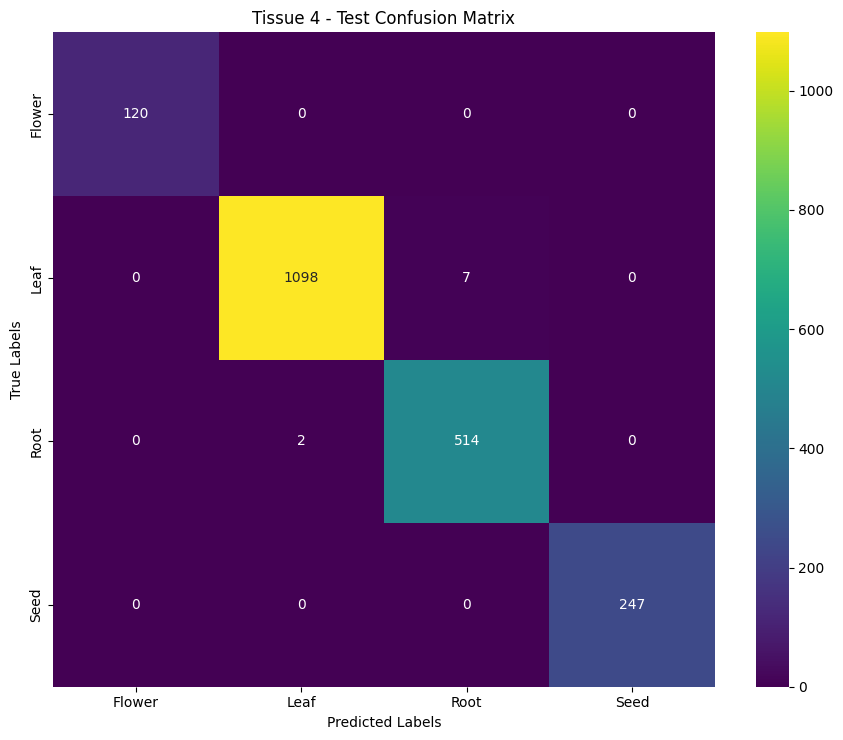

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
category_names = ["Flower", "Leaf", "Root", "Seed"]
cm = confusion_matrix(y_test["tissue_6"], m_4.predict(x_test))
plt.rcParams["figure.figsize"] = [9, 7.5]
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                 xticklabels=category_names, yticklabels=category_names)
ax.set_xlabel("Predicted Labels"); ax.set_ylabel("True Labels")
ax.set_title("Tissue 4 - Test Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/Tissue_4_Test_ConfusionMatrix.png", dpi=300)
plt.show()

## Summary and limitations

- **Reproduced:** the tissue-4 (Flower / Leaf / Root / Seed) random forest from the authors' archived MRN BioProject-disjoint split, with their exact final hyperparameters, evaluated with their metrics on the held-out test set.
- **Not reproduced here:** SRA reprocessing (GEMmaker/Kallisto, ~3 months of HPC time), the normalization comparison ANOVA, age (DAL) regression, learning curves, SMOTE and Boruta branches — all documented in the authors' GitLab notebooks.
- **Determinism note:** the archived pickle fixes the BioProject-disjoint split; the only unstated randomness is scikit-learn's `max_features=700` subsampling, so metrics may differ from the paper in the 3rd–4th decimal.
- **Memory note:** the decompressed matrices need several GB; on the standard Colab CPU runtime (12.7 GB) keep this notebook as the only heavy process.

**日本語まとめ:** 本ノートブックは、著者らが公開したMRN正規化・BioProject分離済みのtissue-4分割データを用い、論文と同一のハイパーパラメータでランダムフォレストを再学習し、テストセットでaccuracy・マクロF1・混同行列を検証します。SRAの再処理や年齢回帰などは対象外です。